#### ***Data Description***

- `mpg`: miles per gallon
- `cyl`: number of cylinders
- `disp`: engine displacement (cu. inches) or engine size
- `hp`: horsepower
- `wt`: vehicle weight (lbs.)
- `acc`: time taken to accelerate from O to 60 mph (sec.)
- `yr`: model year (modulo 100)
- `origin`: origin of car (1 - American, 2 - European, 3 - Japanese)
- `car name`: car model name 

Missing data values are marked by series of question marks.

***t-SNE***

***Importing necessary libraries***

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

# Removes the limit from the number of displayed columns
pd.set_option("display.max_columns", None)
# Changes the limit of number of displayed rows to 200
pd.set_option("display.max_rows", 200)

# suppress warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv("data/11_auto-mpg.csv")

data.shape

(398, 9)

In [3]:
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


We will drop the non-numerical variables. Remember, 'origin' is categorical.

In [4]:
# dropping car_name  and origin
cData = data.copy()
cData = cData.drop(['car name','origin'], axis=1)
cData.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year
0,18.0,8,307.0,130,3504,12.0,70
1,15.0,8,350.0,165,3693,11.5,70
2,18.0,8,318.0,150,3436,11.0,70
3,16.0,8,304.0,150,3433,12.0,70
4,17.0,8,302.0,140,3449,10.5,70


### Dealing with Missing Values

In [5]:
# isdigit()? on 'horsepower' 
hpIsDigit = pd.DataFrame(cData.horsepower.str.isdigit())  # if the string is made of digits store True else False

# print isDigit = False!
cData[hpIsDigit['horsepower'] == False]   # from temp take only those rows where hp has false

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year
32,25.0,4,98.0,?,2046,19.0,71
126,21.0,6,200.0,?,2875,17.0,74
330,40.9,4,85.0,?,1835,17.3,80
336,23.6,4,140.0,?,2905,14.3,80
354,34.5,4,100.0,?,2320,15.8,81
374,23.0,4,151.0,?,3035,20.5,82


There are various ways to handle missing values. Drop the rows, replace missing values with median values etc. of the 398 rows 6 have NaN in the hp column. We could drop those 6 rows - which might not be a good idea under all situations. Here, we will replace them with their median values. First replace '?' with NaN, and then replace NaN with median.

In [6]:
cData = cData.replace('?', np.nan).astype('float64')  # replace ? with NaN and convert the entire dataframe to float
cData[cData['horsepower'].isnull()]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year
32,25.0,4.0,98.0,NaN,2046.0,19.0,71.0
126,21.0,6.0,200.0,NaN,2875.0,17.0,74.0
330,40.9,4.0,85.0,NaN,1835.0,17.3,80.0
336,23.6,4.0,140.0,NaN,2905.0,14.3,80.0
354,34.5,4.0,100.0,NaN,2320.0,15.8,81.0
374,23.0,4.0,151.0,NaN,3035.0,20.5,82.0


In [7]:
# checking median values of columns
cData.median()

mpg               23.0
cylinders          4.0
displacement     148.5
horsepower        93.5
weight          2803.5
acceleration      15.5
model year        76.0
dtype: float64

In [8]:
cData = cData.fillna(cData.median())  # fill NaN with median values
cData.isnull().sum()  # check if any NaN values are present

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
dtype: int64

#### ***Bivariate Plots***

A bivariate analysis among the different independent variables can be done using scatter matrix plot. Seaborn libs create a dashboard reflecting useful information about the dimensions. The result can be stored as a .png file.

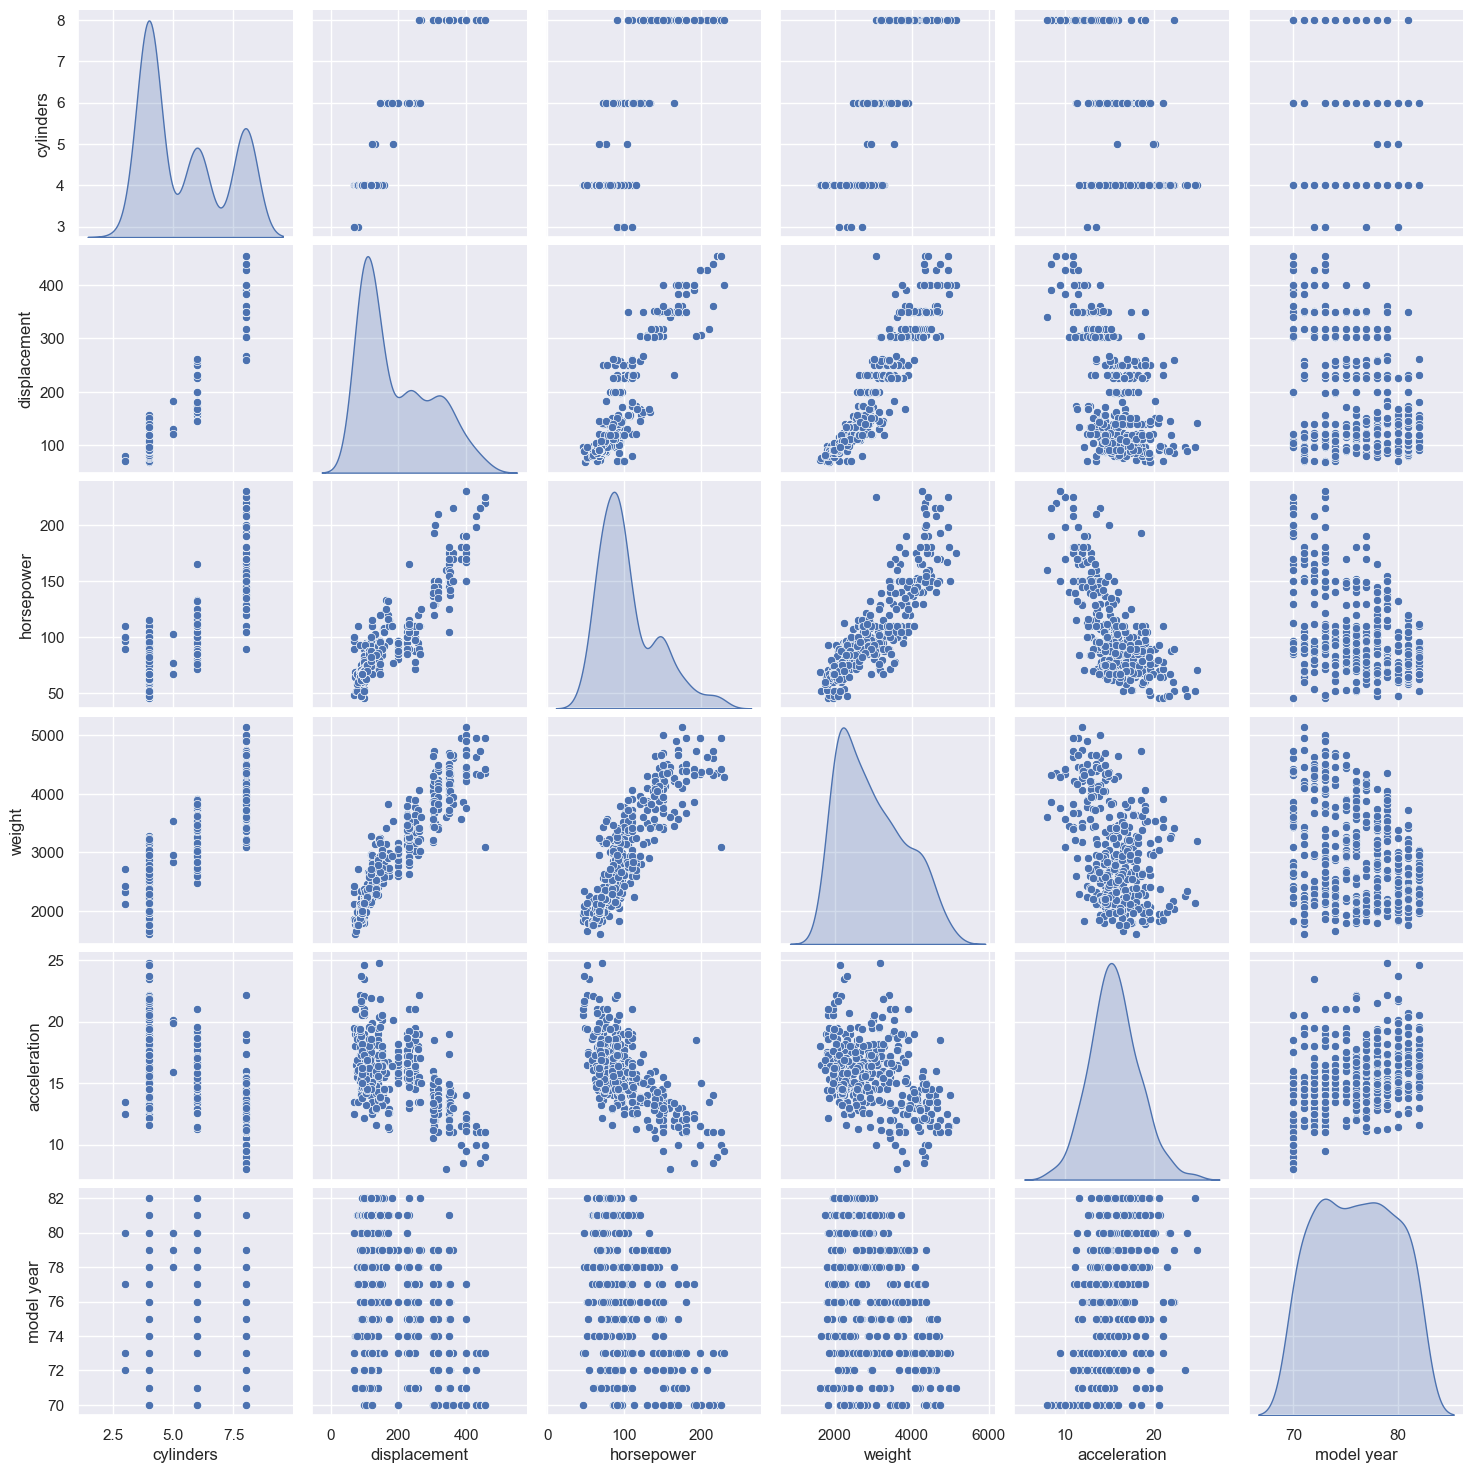

In [9]:
# independent variables
df= cData.drop(['mpg'], axis=1)
# the dependent variable
y = cData[['mpg']]

sns.pairplot(df, diag_kind='kde');   # to plot density curve instead of histogram on the diag

In [10]:
# scaling the data
from scipy.stats import zscore
X = df.apply(zscore)
X.head()

,cylinders,displacement,horsepower,weight,acceleration,model year
0,1.498191,1.090604,0.673118,0.630870,-1.295498,-1.627426
1,1.498191,1.503514,1.589958,0.854333,-1.477038,-1.627426
2,1.498191,1.196232,1.197027,0.550470,-1.658577,-1.627426
3,1.498191,1.061796,1.197027,0.546923,-1.295498,-1.627426
4,1.498191,1.042591,0.935072,0.565841,-1.840117,-1.627426


#### ***Applying t-SNE technique***

In the next few lines of code will be projecting the 6-dimensional data to two-dimensions using t-SNE.

**Note**: We only use the features for dimensionality reduction, we don't need the dependent variable.

In [11]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=8)
X_reduced = tsne.fit_transform(X)

In [12]:
X_reduced.shape

(398, 2)

In [13]:
reduced_data_df = pd.DataFrame(data = X_reduced, columns = ['Component 1', 'Component 2'])

In [14]:
reduced_data_df.tail()

,Component 1,Component 2
393,-6.714106,-5.426157
394,-12.432290,4.816484
395,-10.043587,-10.223565
396,-8.203756,0.450962
397,-7.807161,1.192477


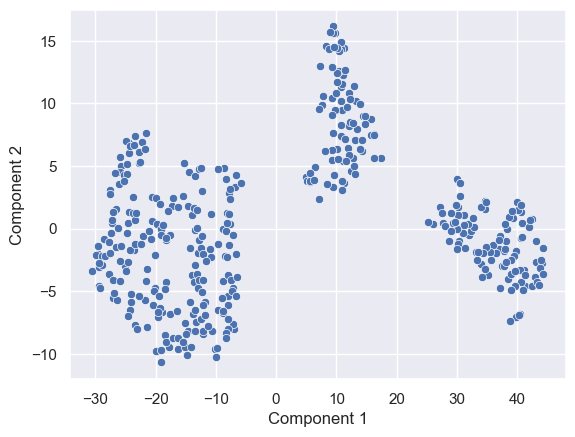

In [15]:
sns.scatterplot(x=reduced_data_df['Component 1'],y=reduced_data_df['Component 2']);

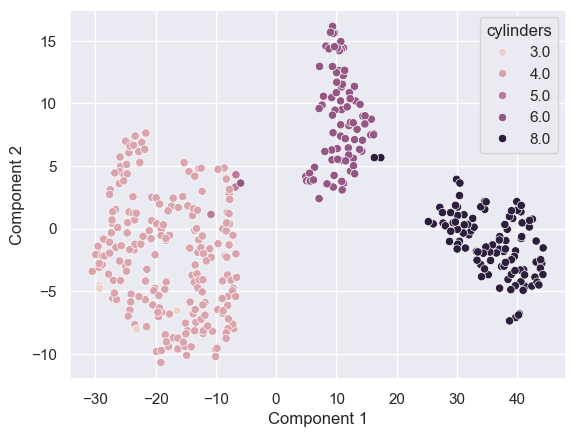

In [16]:
# Lets see scatter plot of the data w.r.t number of cylinders
sns.scatterplot(x=reduced_data_df['Component 1'],y=reduced_data_df['Component 2'],hue=cData.cylinders);

# Seaborn’s hue parameter doesn’t require the column to be in the same DataFrame — 
# it just needs a Series or array that aligns with the x and y values by index.

***Observations***

- *3 different groups of observations are visible.*
- *Cars with larger numbers of cylinders (8) seem to be in one group, cars with small number of cylinders (3,4) seem to be in different group, and cars with medium number (4,5,6) of cylinders seem to form another group.*

In [17]:
# Lets assign points to the 3 different groups
def grouping(x):
    first_component = x['Component 1']
    second_component = x['Component 2']
    if first_component< 0: 
        return 'group_1'
    if first_component >=0 and first_component <= 20:
        return 'group_2'
    if first_component> 0: 
        return 'group_3'

In [18]:
reduced_data_df['different_groups'] = reduced_data_df.apply(grouping,axis=1)

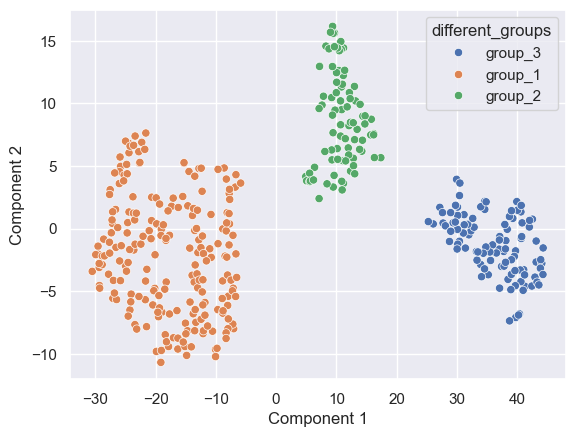

In [19]:
sns.scatterplot(x=reduced_data_df['Component 1'],y=reduced_data_df['Component 2'],hue=reduced_data_df['different_groups']);

In [20]:
df['different_groups'] = reduced_data_df['different_groups'] 

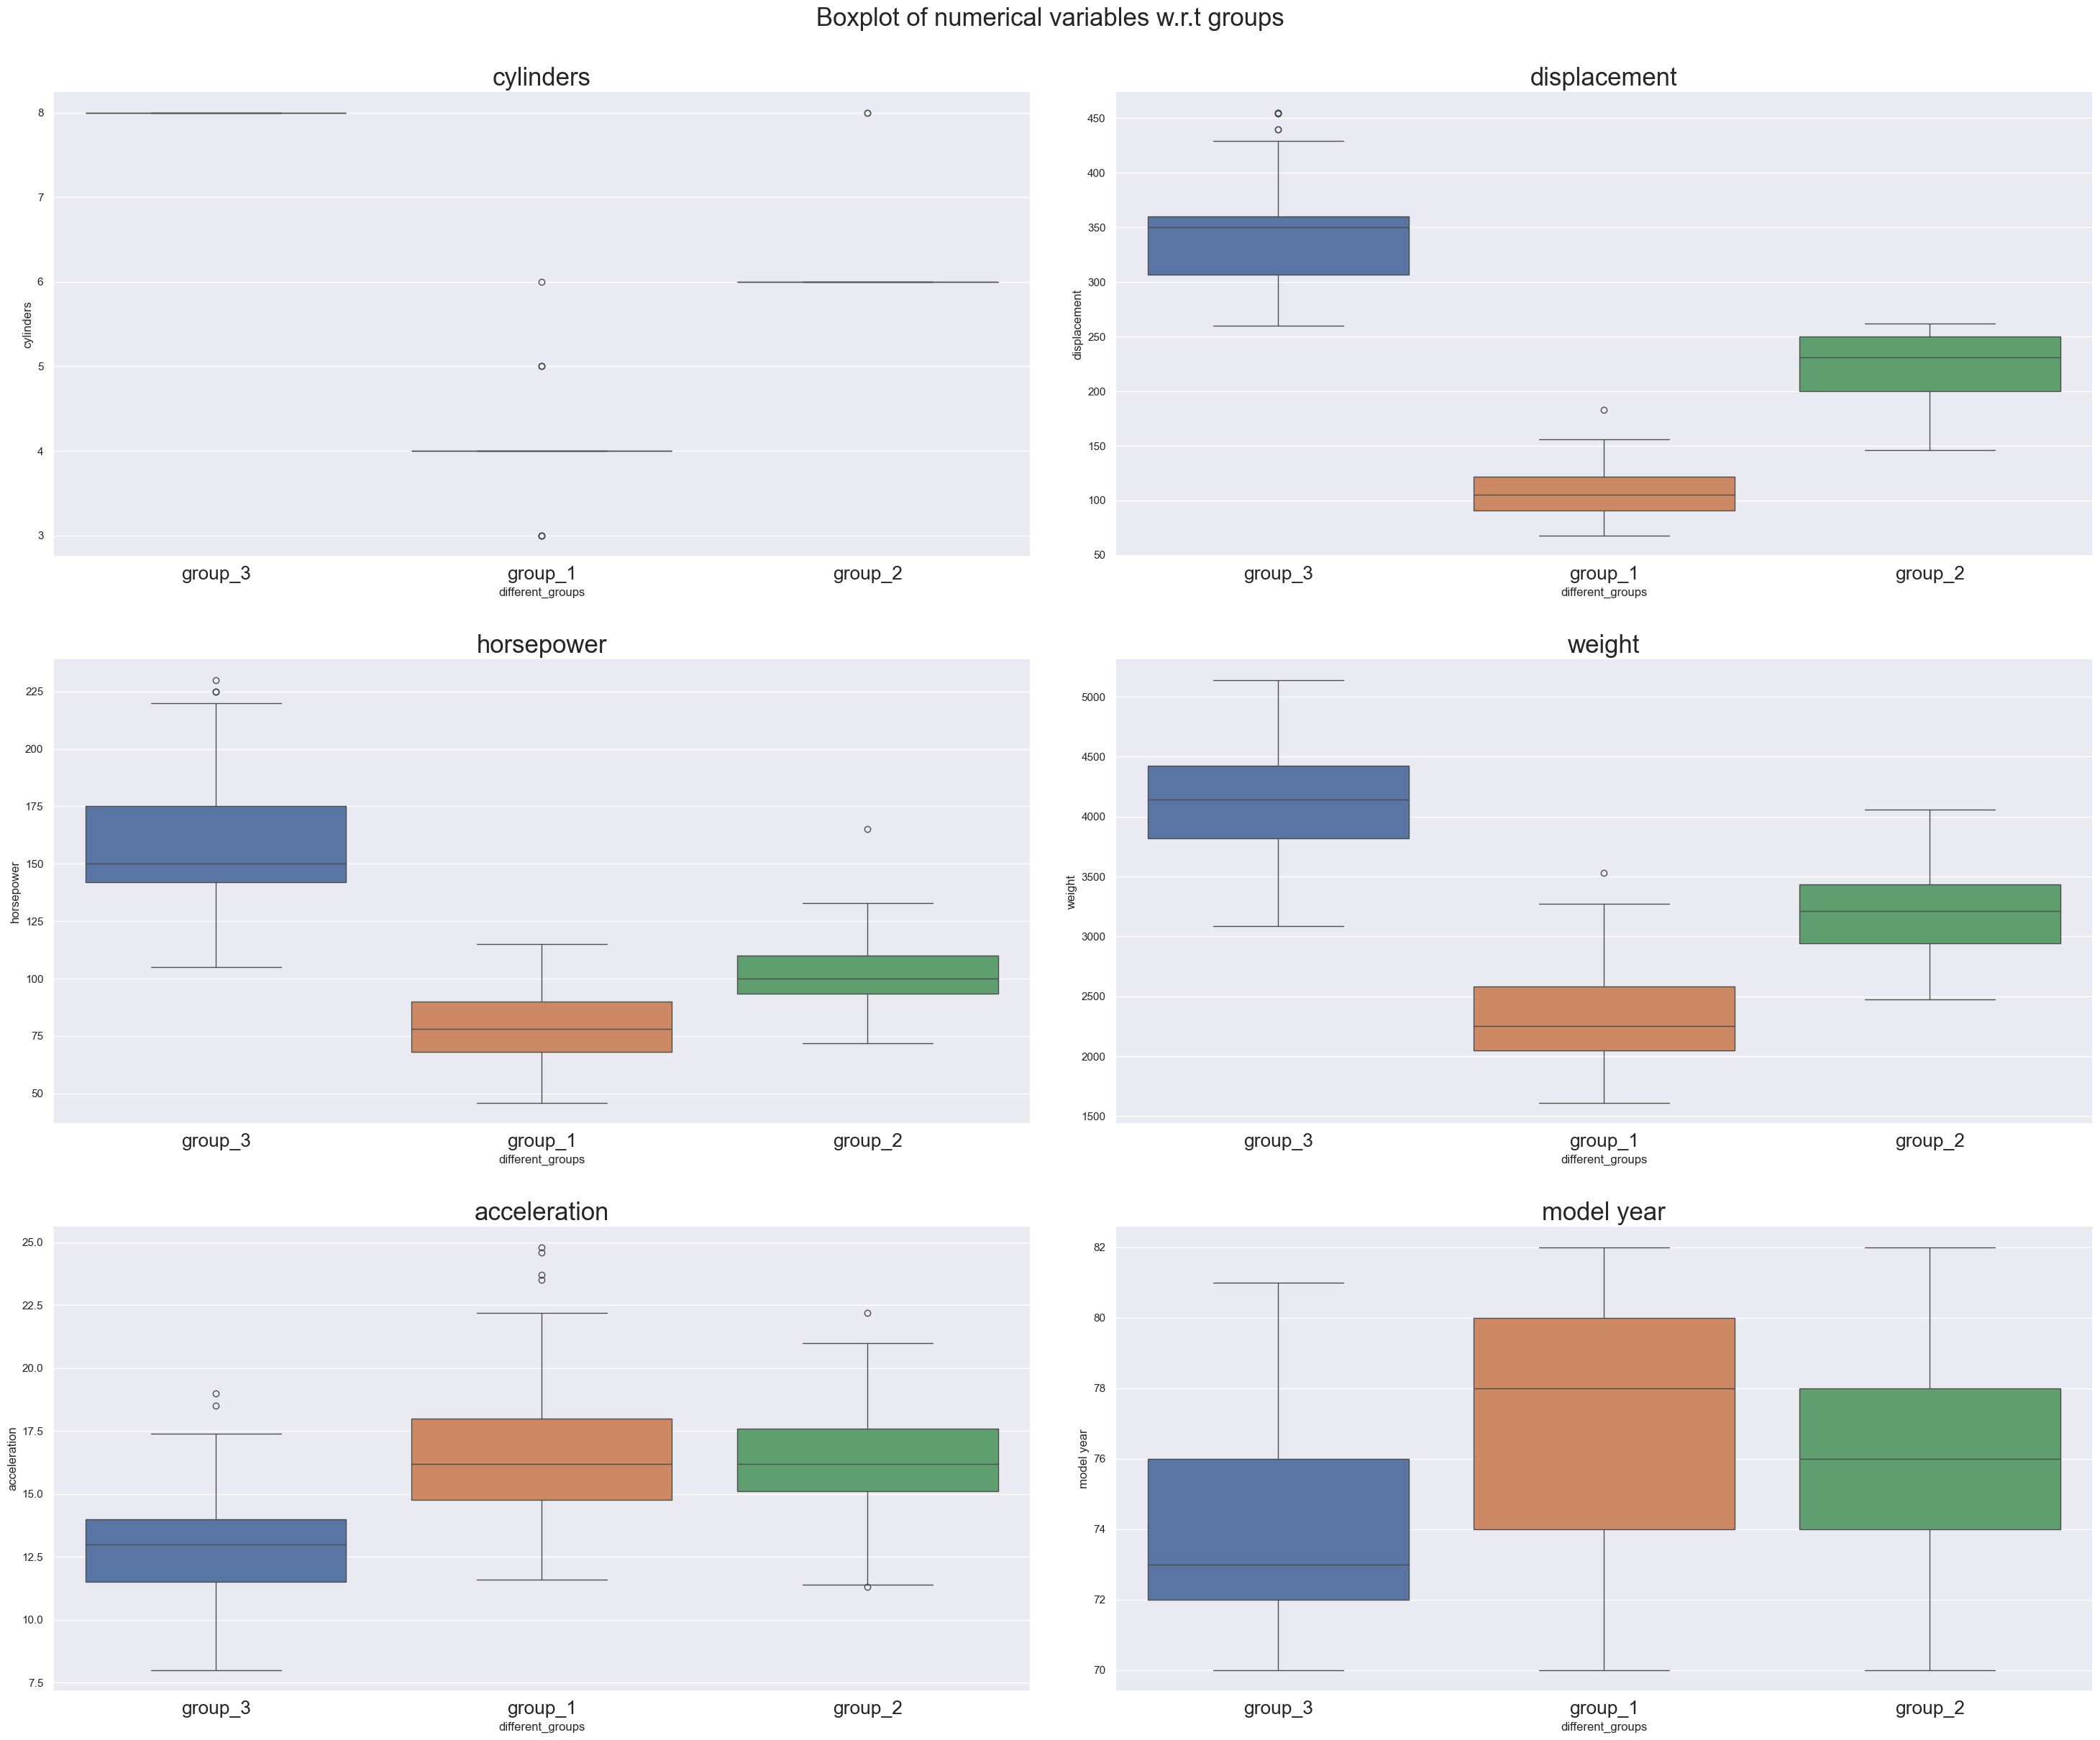

In [21]:
# Lets make boxplot of each numerical variables w.r.t 3 different groups

all_col = df.iloc[:,:-1].columns.tolist()
fig, axes = plt.subplots(3, 2,  figsize=(30, 25))
fig.suptitle('Boxplot of numerical variables w.r.t groups',fontsize = 25)
counter = 0
for ii in range(3):
    sns.boxplot(ax=axes[ii][0],y=df[all_col[counter]],x = df['different_groups'], hue=df['different_groups'])
    axes[ii][0].set_title(all_col[counter],fontsize = 25)
    axes[ii][0].set_xticklabels( axes[ii][0].get_xmajorticklabels(),fontsize = 19)
    counter = counter+1
    sns.boxplot(ax=axes[ii][1],y=df[all_col[counter]],x = df['different_groups'], hue=df['different_groups'])
    axes[ii][1].set_title(all_col[counter],fontsize = 25)
    axes[ii][1].set_xticklabels( axes[ii][1].get_xmajorticklabels(),fontsize = 19)
    counter = counter+1
    
fig.tight_layout(pad=3.0)

***Observations***

***Group 1***:
- *Its number of  cylinders are low*
- *Its engine displacement is very low*
- *Its horse power is also low*
- *Its weight is also medium*
- *Its acceleration is high*
- *50 % of the cars are made after years 1978 which is relatively new*

***Group 2***:
- *It has medium number of cylinders*
- *Its engine displacement is medium*
- *Its horse power is also medium*
- *Its weight is also high*
- *Its acceleration is medium to high*
- *Its model year ranges from 1970 to 1982*

***Group 3***:
- *It has high number of cylinders*
- *Its engine displacement if very high*
- *Its horse power is also high*
- *Its weight is also high*
- *Its acceleration is low which is obvious because cars are very heavy*
- *Its model year is low indicating these cars are very old*
   

#### ***Lets us compare mpg (miles per gallon) vs different groups obtained from t-SNE***

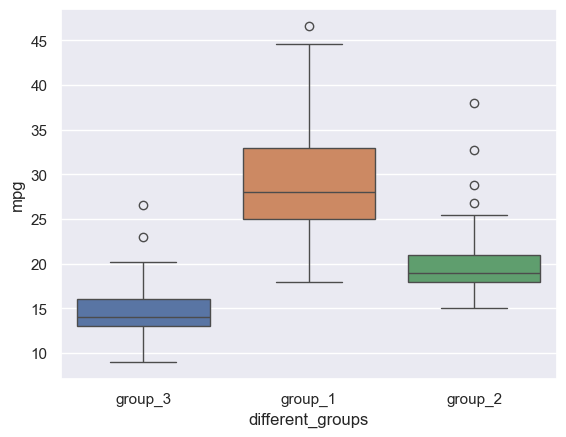

In [22]:
sns.boxplot(y=cData.mpg, x= df.different_groups, hue=df.different_groups);

***Observations***
- Group 1: mpg is high
- Group 2: mpg is medium
- Group 3: mpg is low

#### ***Lets us make scatter plot of first and second component of PCA***

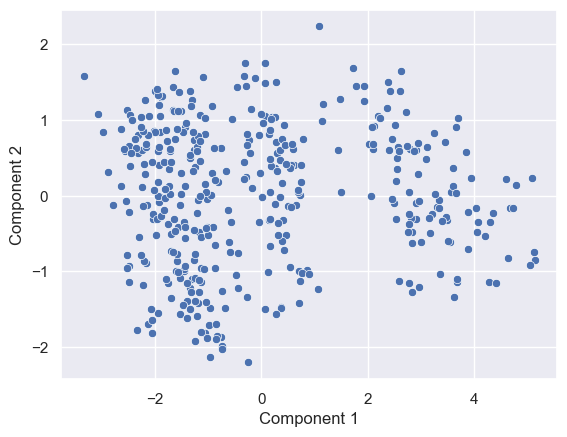

In [23]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_reduced_pca = pca.fit_transform(X)

# storing results in a dataframe
reduced_data_df_pca = pd.DataFrame(data = X_reduced_pca, columns = ['Component 1', 'Component 2']);
sns.scatterplot(x=reduced_data_df_pca.iloc[:,0],y=reduced_data_df_pca.iloc[:,1]);

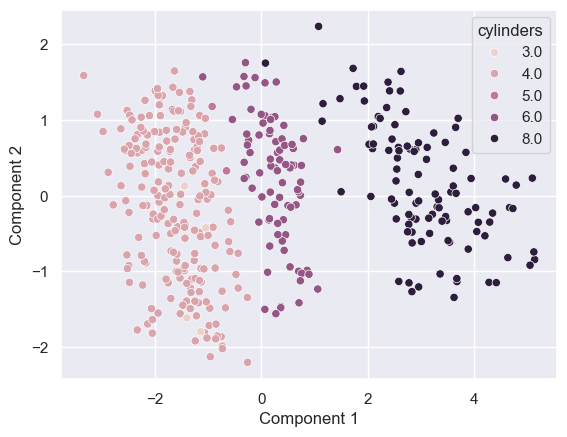

In [24]:
# Lets us plot scatter plot of first 2 component of PCA w.r.t number of number of cylinders
sns.scatterplot(x=reduced_data_df_pca.iloc[:,0],y=reduced_data_df_pca.iloc[:,1],hue=cData.cylinders);

***The groups of data points are not as separable as it is case of t-SNE dimensionality reduction***


#### ***Running t-SNE with different values of perplexity***

Visualizing the lower dimensional representation of data for different values of perplexity


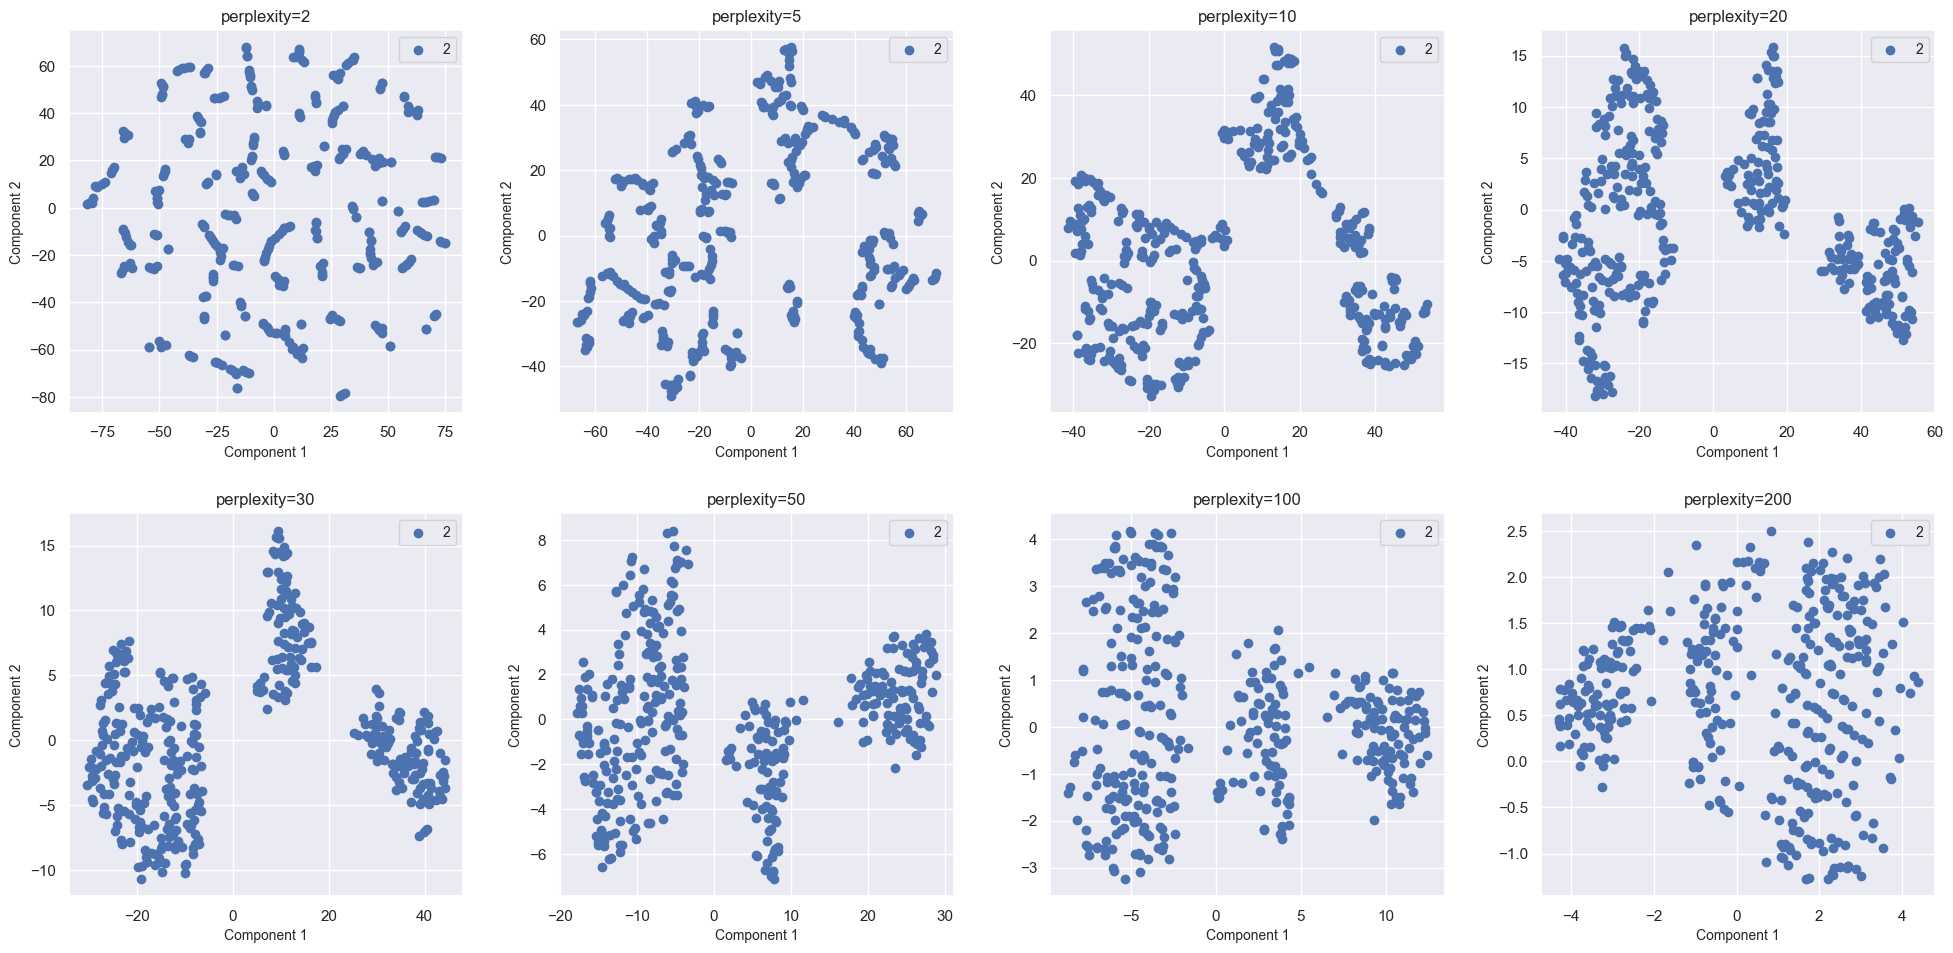

In [25]:
perplexity = [2,5,10,20,30,50,100,200]

plt.figure(figsize=(20,10))
print("Visualizing the lower dimensional representation of data for different values of perplexity")

for i in range(len(perplexity)):
    tsne = TSNE(n_components=2, perplexity=perplexity[i], n_jobs=-2, random_state=42)
    # n_jobs specifies the number of parallel jobs to run
    # -2 means using all processors except one
    X_red = tsne.fit_transform(X)
    
    red_data_df = pd.DataFrame(data = X_red, columns = ['Component 1', 'Component 2'])
    
    plt.subplot(2,int(len(perplexity)/2),i+1)
    
    plt.xlabel('Component 1',fontsize=10)
    plt.ylabel('Component 2',fontsize=10)
    plt.title("perplexity="+str(perplexity[i]))
    plt.scatter(red_data_df.loc[:, 'Component 1'], red_data_df.loc[:, 'Component 2'])#, 
    plt.legend(perplexity,prop={'size': 10})
    plt.tight_layout(pad=2)

#### ***Observations***

* *With low perplexity value (2), data points are very scattered and sparse.*
* *With very high value of perplexity (100 and 200), the data points are spread through out the space and the groups formed are not clearly separable.*
* *With perplexity values ranging from 5 to 50, three distinct groups are clearly visible.*

***In general, the range  of values recommended for perplexity is between 5 to 50.***